   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.1 MB/s eta 0:00:00
🚀 Starting Knova Synthetic Data Generation (Step 1 - Balanced Telemetry)...
Generating 2000 users...
Generating 10000 content items...
Simulating balanced telemetry interactions...


Generating Telemetry: 100%|██████████| 59968/59968 [00:21<00:00, 2803.76it/s]


Saving datasets...
✅ Generation Complete!
Users: 2000, Content: 10000, Interactions: 59968


/tmp/ipykernel_1414/445900492.py:414: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df_quiz, x='quiz_correct', y='difficulty_gap', ax=axs[1, 1], palette="Set2")


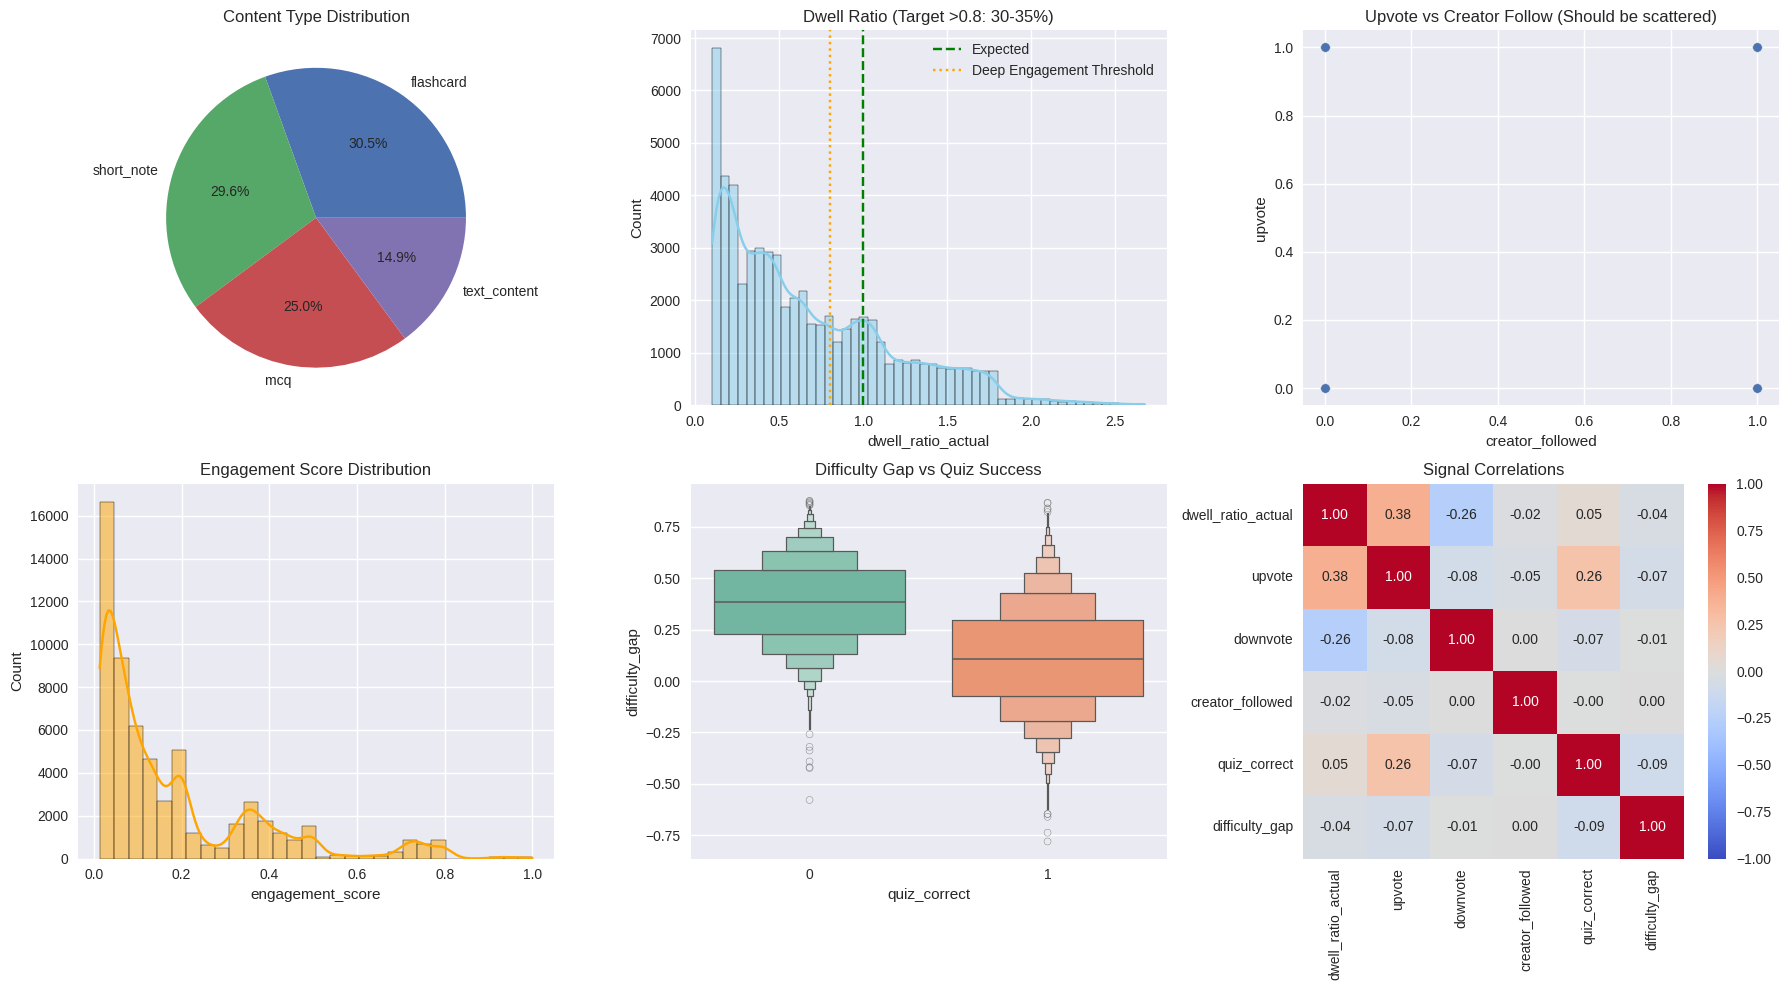


🔍 Diagnostics:
   Dwell > 0.8 Rate:      34.0% (Target: 30-35%)
   Upvote Rate:           9.5% (Target: 10-14%)
   Downvote Rate:         6.0% (Target: 5-7%)
   Corr(Follow, Upvote):  -0.05 (Target: < 0.50)
   Flashcard Flip Rate:   51.9% (Target: 45-65%)
   Avg Flip Time:         2.68s (Target: 2.0-5.0s)


In [2]:
# ==============================================================================
# STEP 1: SYNTHETIC DATA GENERATION (Knova Engine - v3.1 Balanced + Flip Fix)
# ==============================================================================
!pip install faker pandas numpy matplotlib seaborn tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
from faker import Faker

# Initialize Seeds for Reproducibility
fake = Faker()
np.random.seed(42)
random.seed(42)

print("🚀 Starting Knova Synthetic Data Generation (Step 1 - Balanced Telemetry)...")

# ==========================================
# 1. CONFIGURATION & TOPIC KNOWLEDGE BASE
# ==========================================
N_USERS = 2000
N_CONTENT = 10000

TOPIC_BANK = {
    "DBMS": ["SQL", "Indexing", "ACID properties", "Normalization", "NoSQL", "Primary Key"],
    "Macroeconomics": ["GDP calculation", "Inflation metrics", "Fiscal policy", "Monetary policy"],
    "Cell Biology": ["Mitosis", "Organelles", "Cell membrane", "ATP synthesis", "Prokaryotes"],
    "Structural Engineering": ["Concrete mix", "Beam deflection", "Shear force", "Bending moment"],
    "Classical Mechanics": ["Newton's laws", "Kinematics", "Vector math", "Torque", "Friction"],
    "Programming Fundamentals": ["Python", "JavaScript", "OOP", "Recursion", "Memory management"],
    "History of Nepal": ["Lichchhavi period", "Malla dynasty", "Unification era", "Bhimsen Thapa"],
    "Financial Accounting": ["Balance sheets", "Income statements", "Cash flow", "Double entry"],
    "Geomorphology": ["Plate tectonics", "Rock cycle", "River erosion", "Glacial landforms"],
    "Modern English Fiction": ["George Orwell", "Dystopian fiction", "Post-colonialism"],
    "Fluid Mechanics": ["Bernoulli equation", "Reynolds number", "Viscosity", "Pipe flow"],
    "Genetics": ["DNA replication", "RNA transcription", "Mendelian laws", "Mutation", "CRISPR"],
    "Adventure Tourism": ["Everest Base Camp", "Annapurna Circuit", "Mountaineering permits"],
    "Linear Algebra": ["Matrices", "Eigenvalues", "Vector spaces", "Matrix multiplication"],
    "Nepali Literature": ["Laxmi Prasad Devkota", "Muna Madan", "Parijat", "Shirishko Phool"],
    "Machine Learning": ["Supervised learning", "Regression", "Decision trees", "LightGBM"],
    "Thermodynamics": ["Entropy", "Laws of thermodynamics", "Wave-particle duality"],
    "Corporate Finance": ["Nepal Stock Exchange", "Portfolio diversification", "Capital budgeting"],
    "Hydrology": ["Rainfall-runoff", "Catchment area", "Groundwater flow", "Hydrograph"],
    "Human Anatomy": ["Cardiovascular system", "Synaptic transmission", "Endocrine glands"],
    "Web Development": ["Frontend", "Backend", "APIs", "REST architecture", "React"],
    "Microeconomics": ["Monopoly pricing", "Oligopoly", "Consumer surplus", "Opportunity cost"],
    "Organic Chemistry": ["Hydrocarbons", "Functional groups", "Resonance structures"],
    "Soil Mechanics": ["Soil compaction", "Bearing capacity", "Effective stress", "Slope stability"],
    "Calculus": ["Derivatives", "Integration", "Limits", "Gradient descent"],
    "Cultural Tourism": ["Lumbini pilgrimage", "Buddhist circuits", "Pashupatinath heritage"],
    "Probability & Stats": ["Bayes theorem", "Normal distribution", "Standard deviation"],
    "HR Management": ["Talent acquisition", "Performance appraisal", "Labor relations"],
    "Nepalese Arts": ["Pagoda style", "Shikhara architecture", "Thangka paintings"],
    "Environmental Science": ["Carbon cycle", "Biodiversity tracking", "Trophic levels"],
    "Discrete Mathematics": ["Graph theory", "Set theory", "Combinatorics", "Boolean algebra"],
    "Strategic Management": ["SWOT analysis", "Porter's five forces", "Market penetration"],
    "Psychology": ["Cognitive bias", "Classical conditioning", "Defense mechanisms"],
    "Pharmacology": ["Pharmacokinetics", "Drug receptors", "Antibiotics mechanism"],
    "Moral Science": ["Utilitarianism", "Deontology", "Virtue ethics", "Moral dilemmas"],
    "Architectural History": ["Brutalism", "Gothic vaulting", "Bauhaus philosophy"],
    "Computer Vision": ["Convolutional layers", "Image segmentation", "Edge detection"],
    "Graphic Design": ["Typography", "Color theory", "Grid systems", "UI layouts"],
    "Astronomy": ["Stellar evolution", "Black holes", "Redshift", "Kepler's laws"],
    "Philosophy": ["Dualism", "Empiricism", "Rationalism", "Consciousness"],
    "Archeology": ["Stratigraphy", "Radiocarbon dating", "Artifact conservation"],
    "Linguistics": ["Syntax trees", "Phonemes", "Morphology", "Semantic shifting"],
    "World Mythology": ["Archetypes", "Monomyth", "Oral traditions", "Deity pantheons"],
    "International Law": ["Sovereignty", "Treaty ratification", "Humanitarian law"],
    "Climatology": ["Atmospheric pressure", "Jet streams", "El Nino", "Greenhouse forcing"],
    "Political Philosophy": ["Social contract", "Separation of powers", "Totalitarianism"],
    "Music Theory": ["Harmonic progression", "Counterpoint", "Tempo signatures"],
    "Agronomy": ["Soil nutrients", "Crop rotation", "Irrigation efficiency"],
    "Sports Science": ["Biomechanics", "Aerobic threshold", "Kinematics", "Ball trajectory"],
    "Cinema Studies": ["Cinematography", "Screenplay structure", "Color grading"],
    "Geopolitics": ["Supply chain logistics", "Trade embargos", "Diplomatic protocols"],
    "Cricket Analytics": ["Aerodynamics", "Fluid mechanics", "Spin vectors", "Data analytics"]
}

TOPICS_LIST = list(TOPIC_BANK.keys())

CONTENT_TYPES = {
    'text_content': 0.15,
    'short_note': 0.30,
    'mcq': 0.25,
    'flashcard': 0.30
}

# ==========================================
# 2. SMART CONTENT GENERATION FUNCTIONS
# ==========================================

def generate_mcq(topic):
    keywords = TOPIC_BANK[topic]
    k_sample = random.sample(keywords, min(4, len(keywords)))
    k1, k2 = k_sample[0], k_sample[1]
    k3 = k_sample[2] if len(k_sample) > 2 else k1
    k4 = k_sample[3] if len(k_sample) > 3 else k2
    patterns = [
        f"Which of the following best describes {k1} in the context of {topic}?",
        f"How does {k1} influence {k2}?",
        f"What is the primary function of {k1}?",
        f"In {topic}, which principle explains {k1}?"
    ]
    question = random.choice(patterns)
    correct_answer = f"It directly relates to {k2} and determines {k3}."
    distractors = [
        f"It is unrelated to {k2} but affects {k4}.",
        f"It only applies when {k3} is zero.",
        f"It is a deprecated concept in modern {topic}."
    ]
    options = [correct_answer] + distractors
    random.shuffle(options)
    return {
        'description': question,
        'options': str(options),
        'correct_index': options.index(correct_answer),
        'explanation': f"{k1} is fundamental because it governs {k2}.",
        'word_count': len(question.split()) + sum(len(o.split()) for o in options)
    }

def generate_flashcard(topic):
    keywords = TOPIC_BANK[topic]
    k1, k2 = random.sample(keywords, min(2, len(keywords)))
    front = f"Define {k1}."
    back = f"{k1} refers to the process of {k2} within {topic}."
    return {'front_desc': front, 'back_desc': back, 'word_count': len(front.split()) + len(back.split())}

def generate_short_note(topic):
    keywords = TOPIC_BANK[topic]
    k1, k2, k3 = random.sample(keywords, min(3, len(keywords)))
    content = f"**Key Insight:** {k1} is essential for mastering {topic}. Note that {k2} often interacts with {k3}."
    return {'description': content, 'word_count': len(content.split())}

def generate_text_content(topic):
    keywords = TOPIC_BANK[topic]
    k1, k2, k3 = random.sample(keywords, min(3, len(keywords)))
    title = f"Deep Dive: Understanding {k1} in {topic}"
    body = f"In the field of {topic}, {k1} stands out as a pivotal concept. Researchers have long studied how {k1} influences {k2}. Recent advancements suggest that integrating {k3} can lead to significant improvements."
    return {'title': title, 'description': body, 'word_count': len(title.split()) + len(body.split())}

# ==========================================
# 3. GENERATE USERS (2,000)
# ==========================================
print(f"Generating {N_USERS} users...")

users_data = []
for i in range(N_USERS):
    name = fake.name()
    n_interests = np.random.randint(2, 6)
    user_interests = random.sample(TOPICS_LIST, n_interests)
    primary_interest = user_interests[0]

    # FIX: Beta distribution for wider skill range
    base_skill = np.random.beta(2, 2) * 0.9 + 0.05

    curiosity_score = np.random.uniform(0.5, 1.0)
    n_interactions = int(np.random.normal(loc=40, scale=15) * curiosity_score)
    n_interactions = max(15, min(n_interactions, 85))

    users_data.append({
        'user_id': i + 1,
        'name': name,
        'interests': "|".join(user_interests),
        'primary_topic': primary_interest,
        'base_skill_level': round(base_skill, 3),
        'curiosity_score': round(curiosity_score, 3),
        'total_expected_interactions': n_interactions
    })

df_users = pd.DataFrame(users_data)

# ==========================================
# 4. GENERATE CONTENT (10,000)
# ==========================================
print(f"Generating {N_CONTENT} content items...")

content_data = []
type_keys = list(CONTENT_TYPES.keys())
type_probs = list(CONTENT_TYPES.values())

for i in range(N_CONTENT):
    ctype = np.random.choice(type_keys, p=type_probs)
    topic = np.random.choice(TOPICS_LIST)
    difficulty = np.random.uniform(0.2, 0.95)

    if ctype == 'mcq':
        gen = generate_mcq(topic)
        row = {
            'content_id': i + 1, 'type': ctype, 'topic': topic,
            'difficulty_score': round(difficulty, 3), 'word_count': gen['word_count'],
            'title': None, 'description': gen['description'],
            'front_desc': None, 'back_desc': None,
            'options': gen['options'], 'correct_index': gen['correct_index'],
            'explanation': gen['explanation'], 'flip_threshold_sec': None
        }
    elif ctype == 'flashcard':
        gen = generate_flashcard(topic)
        row = {
            'content_id': i + 1, 'type': ctype, 'topic': topic,
            'difficulty_score': round(difficulty, 3), 'word_count': gen['word_count'],
            'title': None, 'description': None,
            'front_desc': gen['front_desc'], 'back_desc': gen['back_desc'],
            'options': None, 'correct_index': None, 'explanation': None,
            'flip_threshold_sec': round(np.random.uniform(3, 8), 2)  # ADDED
        }
    elif ctype == 'short_note':
        gen = generate_short_note(topic)
        row = {
            'content_id': i + 1, 'type': ctype, 'topic': topic,
            'difficulty_score': round(difficulty, 3), 'word_count': gen['word_count'],
            'title': None, 'description': gen['description'],
            'front_desc': None, 'back_desc': None,
            'options': None, 'correct_index': None, 'explanation': None,
            'flip_threshold_sec': None
        }
    elif ctype == 'text_content':
        gen = generate_text_content(topic)
        row = {
            'content_id': i + 1, 'type': ctype, 'topic': topic,
            'difficulty_score': round(difficulty, 3), 'word_count': gen['word_count'],
            'title': gen['title'], 'description': gen['description'],
            'front_desc': None, 'back_desc': None,
            'options': None, 'correct_index': None, 'explanation': None,
            'flip_threshold_sec': None
        }

    expected_time = (row['word_count'] / 220) * 60 * (1 + difficulty * 0.5)
    row['expected_read_time_sec'] = round(expected_time, 2)
    content_data.append(row)

df_content = pd.DataFrame(content_data)

# ==========================================
# 5. GENERATE INTERACTIONS (Balanced Telemetry + Flip Logic)
# ==========================================
print("Simulating balanced telemetry interactions...")

interactions_data = []
user_interaction_list = []
for _, user in df_users.iterrows():
    for _ in range(user['total_expected_interactions']):
        user_interaction_list.append(user)

df_user_events = pd.DataFrame(user_interaction_list)
N_TOTAL_EVENTS = len(df_user_events)
df_content_events = df_content.sample(n=N_TOTAL_EVENTS, replace=True).reset_index(drop=True)

# Pre-calculate user follows
user_follows_map = {}
for uid in df_users['user_id']:
    followed_topics = set(random.sample(TOPICS_LIST, int(len(TOPICS_LIST)*0.2)))
    user_follows_map[uid] = followed_topics

for idx in tqdm(range(N_TOTAL_EVENTS), desc="Generating Telemetry"):
    user = df_user_events.iloc[idx]
    content = df_content_events.iloc[idx]

    user_interests = user['interests'].split('|')
    is_interest_match = 1 if content['topic'] in user_interests else 0

    # Skill-Difficulty Gap
    if content['topic'] == user['primary_topic']:
        effective_skill = user['base_skill_level'] * 1.1
    elif is_interest_match:
        effective_skill = user['base_skill_level']
    else:
        effective_skill = user['base_skill_level'] * 0.8
    effective_skill = min(effective_skill, 0.99)
    gap = content['difficulty_score'] - effective_skill

    # --- PERSONA-BASED DWELL ---
    persona = np.random.choice(
        ['skimmer', 'passive', 'engaged', 'deep_learner'],
        p=[0.28, 0.17, 0.30, 0.25]
    )

    # Skip logic (15% chance)
    if random.random() < 0.15:
        dwell_ratio = np.random.uniform(0.05, 0.25)
        skipped = True
    else:
        skipped = False
        if persona == 'skimmer':
            dwell_ratio = np.random.uniform(0.1, 0.5)
        elif persona == 'passive':
            dwell_ratio = np.random.uniform(0.3, 0.65)
        elif persona == 'engaged':
            base = np.random.uniform(0.6, 1.1)
            dwell_ratio = base * (0.75 if gap > 0.3 else 1.0)
        else: # deep_learner
            base = np.random.uniform(0.9, 1.8)
            dwell_ratio = base * (0.80 if gap < -0.3 else 1.0)

    dwell_ratio = max(0.1, dwell_ratio)
    actual_dwell_sec = max(1.0, content['expected_read_time_sec'] * dwell_ratio)

    # Quiz Performance (MCQ Only)
    quiz_success_prob = 0.9 - (gap * 0.8)
    quiz_success_prob = max(0.1, min(0.99, quiz_success_prob))
    did_quiz = 1 if content['type'] == 'mcq' and not skipped else 0
    quiz_correct = 1 if (did_quiz and random.random() < quiz_success_prob) else 0

    # --- RELAXED UPVOTE LOGIC ---
    is_deep_engagement = (dwell_ratio > 0.8)
    upvote = 0

    if is_deep_engagement:
        if quiz_correct == 1 and random.random() > 0.35:
            upvote = 1
        elif is_interest_match == 1 and dwell_ratio > 1.0 and random.random() > 0.45:
            upvote = 1
        elif random.random() > 0.82:
            upvote = 1

    # Downvote: Only natural bounce
    downvote = 1 if (dwell_ratio < 0.25 and random.random() > 0.75) else 0

    # Creator Trust Signal (Decoupled)
    creator_followed = 1 if content['topic'] in user_follows_map[user['user_id']] else 0
    if upvote == 1 and random.random() < 0.3:
        creator_followed = 0

    # --- FLASHCARD FLIP LOGIC (FIXED TIMING) ---
    card_flipped = 0
    flip_time_sec = 0.0

    if content['type'] == 'flashcard' and not skipped:
        if persona == 'deep_learner':   flip_bias = 0.85
        elif persona == 'engaged':      flip_bias = 0.65
        elif persona == 'passive':      flip_bias = 0.35
        else:                           flip_bias = 0.15

        gap_flip_prob = max(0.15, min(0.92, 0.75 - (gap * 0.4)))
        flip_prob = gap_flip_prob * 0.6 + flip_bias * 0.4
        card_flipped = 1 if random.random() < flip_prob else 0

        if card_flipped:
            dwell_ratio *= np.random.uniform(1.1, 1.5)
        else:
            # Thinking hard (no penalty) or skimmed (penalty)
            if dwell_ratio <= 0.8:
                dwell_ratio *= np.random.uniform(0.5, 0.8)

        # Recalculate FIRST, then derive flip_time from updated dwell
        dwell_ratio = max(0.1, dwell_ratio)
        actual_dwell_sec = max(1.0, content['expected_read_time_sec'] * dwell_ratio)

        if card_flipped:
            # Ensure min 2.0s and realistic ratio of total dwell
            flip_time_sec = round(max(2.0, actual_dwell_sec * np.random.uniform(0.35, 0.55)), 2)

    engagement_score = (upvote * 0.3) + (quiz_correct * 0.3) + (min(dwell_ratio, 1.5)/1.5 * 0.2) + (is_interest_match * 0.2)

    interactions_data.append({
        'user_id': user['user_id'],
        'content_id': content['content_id'],
        'topic': content['topic'],
        'is_interest_match': is_interest_match,
        'creator_followed': creator_followed,
        'difficulty_gap': round(gap, 3),
        'dwell_ratio_actual': round(dwell_ratio, 3),
        'actual_dwell_sec': round(actual_dwell_sec, 2),
        'did_quiz': did_quiz,
        'quiz_correct': quiz_correct,
        'upvote': upvote,
        'downvote': downvote,
        'engagement_score': round(engagement_score, 3),
        'card_flipped': card_flipped,
        'flip_time_sec': flip_time_sec
    })

df_interactions = pd.DataFrame(interactions_data)

# ==========================================
# 6. SAVE & VISUALIZE
# ==========================================
print("Saving datasets...")
df_users.to_csv('knova_users.csv', index=False)
df_content.to_csv('knova_content.csv', index=False)
df_interactions.to_csv('knova_interactions.csv', index=False)

print("✅ Generation Complete!")
print(f"Users: {len(df_users)}, Content: {len(df_content)}, Interactions: {len(df_interactions)}")

# --- DIAGNOSTIC PLOTS ---
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# 1. Content Distribution
axs[0, 0].pie(df_content['type'].value_counts(), labels=df_content['type'].value_counts().index, autopct='%1.1f%%')
axs[0, 0].set_title('Content Type Distribution')

# 2. Dwell Ratio Distribution
sns.histplot(df_interactions['dwell_ratio_actual'], bins=50, kde=True, ax=axs[0, 1], color='skyblue')
axs[0, 1].axvline(x=1.0, color='green', linestyle='--', label='Expected')
axs[0, 1].axvline(x=0.8, color='orange', linestyle=':', label='Deep Engagement Threshold')
axs[0, 1].set_title('Dwell Ratio (Target >0.8: 30-35%)')
axs[0, 1].legend()

# 3. Upvote vs Creator Follow
sample = df_interactions.sample(1000)
sns.scatterplot(data=sample, x='creator_followed', y='upvote', alpha=0.5, ax=axs[0, 2])
axs[0, 2].set_title('Upvote vs Creator Follow (Should be scattered)')

# 4. Engagement Score Distribution
sns.histplot(df_interactions['engagement_score'], bins=30, kde=True, ax=axs[1, 0], color='orange')
axs[1, 0].set_title('Engagement Score Distribution')

# 5. Difficulty Gap vs Quiz Correct
df_quiz = df_interactions[df_interactions['did_quiz']==1]
sns.boxenplot(data=df_quiz, x='quiz_correct', y='difficulty_gap', ax=axs[1, 1], palette="Set2")
axs[1, 1].set_title('Difficulty Gap vs Quiz Success')

# 6. Correlation Heatmap
corr_cols = ['dwell_ratio_actual', 'upvote', 'downvote', 'creator_followed', 'quiz_correct', 'difficulty_gap']
corr_matrix = df_interactions[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[1, 2], fmt=".2f")
axs[1, 2].set_title('Signal Correlations')

plt.tight_layout()
plt.show()

# Verification Prints
dwell_high_rate = (df_interactions['dwell_ratio_actual'] > 0.8).mean()
upvote_rate = df_interactions['upvote'].mean()
downvote_rate = df_interactions['downvote'].mean()
follow_upvote_corr = df_interactions['upvote'].corr(df_interactions['creator_followed'])

# Flashcard flip diagnostics (FILTERED CORRECTLY)
fc_interactions = df_interactions[
    df_interactions['content_id'].isin(
        df_content[df_content['type']=='flashcard']['content_id']
    )
]
flip_rate = fc_interactions['card_flipped'].mean()
# FIX: Only average rows where card was actually flipped
avg_flip_time = fc_interactions[fc_interactions['card_flipped']==1]['flip_time_sec'].mean()

print(f"\n🔍 Diagnostics:")
print(f"   Dwell > 0.8 Rate:      {dwell_high_rate:.1%} (Target: 30-35%)")
print(f"   Upvote Rate:           {upvote_rate:.1%} (Target: 10-14%)")
print(f"   Downvote Rate:         {downvote_rate:.1%} (Target: 5-7%)")
print(f"   Corr(Follow, Upvote):  {follow_upvote_corr:.2f} (Target: < 0.50)")
print(f"   Flashcard Flip Rate:   {flip_rate:.1%} (Target: 45-65%)")
print(f"   Avg Flip Time:         {avg_flip_time:.2f}s (Target: 2.0-5.0s)")

🧹 Starting Step 2: Preprocessing & Merging...
   Loaded: Users=2000, Content=10000, Interactions=59968
   ✅ Created 'creator_trust' from 'creator_followed' (Preserving synthetic independence)
✅ Step 2 Complete: Saved 'knova_cleaned.csv'
   ✅ Integrity Check: All critical columns have 0 nulls.


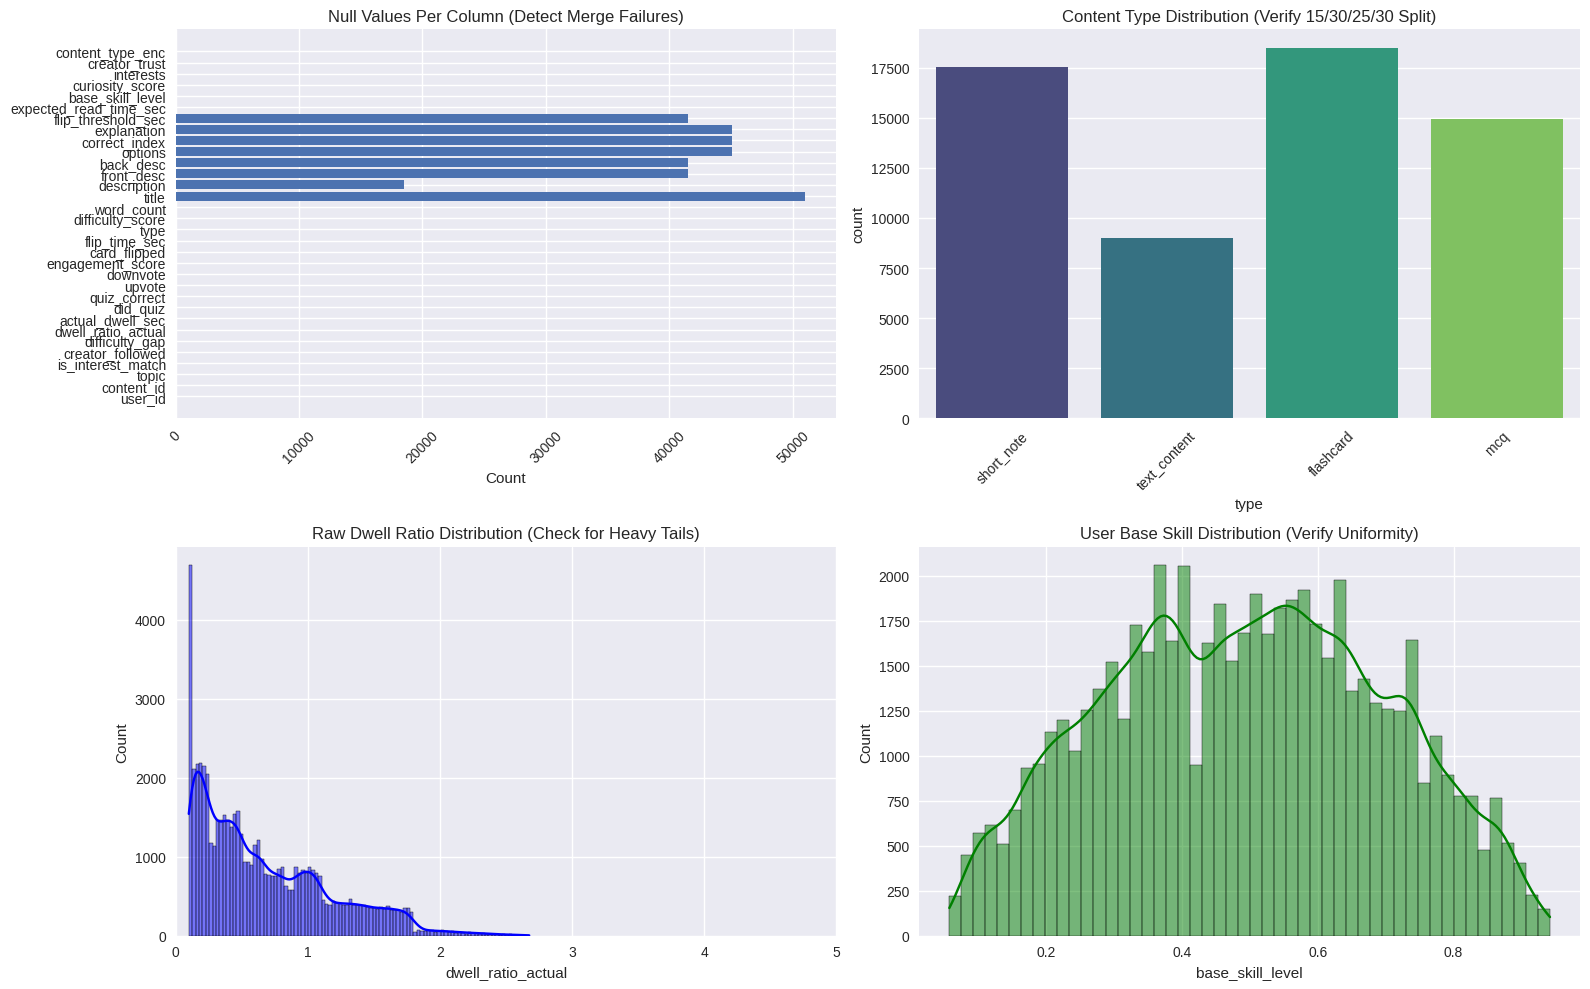

In [3]:
# ==============================================================================
# STEP 2: PREPROCESSING & DATA MERGING
# ==============================================================================
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("🧹 Starting Step 2: Preprocessing & Merging...")

# 1. Load Raw Data
df_users = pd.read_csv('knova_users.csv')
df_content = pd.read_csv('knova_content.csv')
df_interactions = pd.read_csv('knova_interactions.csv')

print(f"   Loaded: Users={len(df_users)}, Content={len(df_content)}, Interactions={len(df_interactions)}")

# 2. Merge Datasets
# Drop 'topic' from content to avoid conflict with interactions (which has the user's view of topic)
df = df_interactions.merge(df_content.drop(columns=['topic']), on='content_id', how='left')
df = df.merge(df_users[['user_id', 'base_skill_level', 'curiosity_score', 'interests']], on='user_id', how='left')

# 3. Handle Missing Values (Cold Start Strategy)
df['base_skill_level'] = df['base_skill_level'].fillna(0.5)
df['curiosity_score'] = df['curiosity_score'].fillna(0.5)
df['is_interest_match'] = df['is_interest_match'].fillna(0)

# --- FIX: Creator Trust Alias ---
# Step 1 generated 'creator_followed' with careful decoupling from upvotes.
# We map it to 'creator_trust' now so Step 3 doesn't regenerate it from scratch.
if 'creator_followed' in df.columns and 'creator_trust' not in df.columns:
    df['creator_trust'] = df['creator_followed'].astype(float)
    print("   ✅ Created 'creator_trust' from 'creator_followed' (Preserving synthetic independence)")

# 4. Encode Categorical Variables
le_type = LabelEncoder()
df['content_type_enc'] = le_type.fit_transform(df['type'])
joblib.dump(le_type, 'knova_type_encoder.pkl')

# 5. Basic Outlier Clipping (Pre-Engineering)
# Soft clip to remove impossible values before engineering
df['dwell_ratio_actual'] = df['dwell_ratio_actual'].clip(0.1, 5.0)
df['actual_dwell_sec'] = df['actual_dwell_sec'].clip(lower=0.1)

# 6. Save Cleaned Intermediate Data
df.to_csv('knova_cleaned.csv', index=False)
print("✅ Step 2 Complete: Saved 'knova_cleaned.csv'")

# Verification Print
critical_cols = ['creator_followed', 'creator_trust', 'base_skill_level', 'curiosity_score', 'is_interest_match']
nulls = df[critical_cols].isnull().sum()
if nulls.sum() == 0:
    print("   ✅ Integrity Check: All critical columns have 0 nulls.")
else:
    print(f"   ⚠️ WARNING: Nulls detected:\n{nulls[nulls > 0]}")

# ==============================================================================
# 📊 DIAGNOSTIC VISUALIZATIONS (Step 2)
# ==============================================================================
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Merge Integrity Check (Nulls per Column)
null_counts = df.isnull().sum()
axs[0, 0].barh(null_counts.index, null_counts.values)
axs[0, 0].set_title('Null Values Per Column (Detect Merge Failures)')
axs[0, 0].set_xlabel('Count')
axs[0, 0].tick_params(axis='x', labelrotation=45)

# Plot 2: Content Type Distribution
sns.countplot(data=df, x='type', ax=axs[0, 1], palette='viridis')
axs[0, 1].set_title('Content Type Distribution (Verify 15/30/25/30 Split)')
axs[0, 1].tick_params(axis='x', labelrotation=45)

# Plot 3: Dwell Ratio Raw Distribution
sns.histplot(data=df, x='dwell_ratio_actual', bins=100, kde=True, ax=axs[1, 0], color='blue')
axs[1, 0].set_title('Raw Dwell Ratio Distribution (Check for Heavy Tails)')
axs[1, 0].set_xlim(0, 5)

# Plot 4: User Skill Distribution
sns.histplot(data=df, x='base_skill_level', bins=50, kde=True, ax=axs[1, 1], color='green')
axs[1, 1].set_title('User Base Skill Distribution (Verify Uniformity)')

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

print("⚙  Starting Step 3: Refined Feature Engineering (Balanced Telemetry - NO LEAKAGE)...")

# 1. LOAD DATA
df = pd.read_csv('knova_cleaned.csv')

# 2. DWELL & VELOCITY
clip_limits = {'flashcard': 2.0, 'short_note': 2.2, 'mcq': 3.0, 'text_content': 2.5}
def clip_dwell_by_type(group):
    ctype = group['type'].iloc[0]
    upper = clip_limits.get(ctype, 2.5)
    group['dwell_ratio_actual'] = group['dwell_ratio_actual'].clip(0.1, upper)
    return group

df = df.groupby('type', group_keys=False).apply(clip_dwell_by_type)
df['dwell_norm_by_type'] = df.groupby('type')['dwell_ratio_actual'].transform(lambda x: (x - x.mean()) / x.std()).clip(-3, 3).fillna(0)

df['read_velocity_raw'] = df['word_count'] / df['actual_dwell_sec'].replace(0, np.nan)
df['read_velocity'] = df.groupby('type')['read_velocity_raw'].transform(lambda x: (x - x.mean()) / x.std()).clip(-3, 3).fillna(0)

# 3. NEW BALANCED TELEMETRY SIGNALS
df['vote_signal'] = (df['upvote'] * 0.3) - (df['downvote'] * 0.7)
df['quiz_engagement'] = (df['did_quiz'] * 0.4) + (df['quiz_correct'] * 0.6)
df['focus_ratio'] = np.where(df['dwell_ratio_actual'] > 2.2, 0.5, 1.0)

# 4. KNOWLEDGE & ALIGNMENT
df['abs_difficulty_gap'] = df['difficulty_gap'].abs()
mastery = df[df['did_quiz'] == 1].groupby(['user_id', 'topic'])['quiz_correct'].agg(['mean']).reset_index()
mastery.columns = ['user_id', 'topic', 'mastery_score']
df = df.merge(mastery, on=['user_id', 'topic'], how='left')
df['mastery_score'] = df['mastery_score'].fillna(0.5)
df['depth_alignment'] = 1 - df['abs_difficulty_gap'].clip(0, 1)
df['kg_readiness'] = (df['mastery_score'] - df['difficulty_score']).clip(-1, 1)

# 5. SANITIZED TARGET (FIXED LEAKAGE)
# Removed creator_trust from here as it is a feature.
df['relevance'] = (
    (df['actual_dwell_sec'] >= df['expected_read_time_sec'] * 0.6).astype(int) * 1 +
    (df['upvote'] == 1).astype(int) * 1 +
    ((df['type'] == 'flashcard') & (df['card_flipped'] == 1)).astype(int) * 1
).clip(0, 3)

print("\nRelevance Distribution (Sanitized):")
print(df['relevance'].value_counts().sort_index())

# 6. CONFIG (14 Features Total)
FEATURES_ALL = [
    'dwell_norm_by_type', 'read_velocity', 'vote_signal', 'quiz_engagement',
    'focus_ratio', 'mastery_score', 'kg_readiness', 'base_skill_level',
    'curiosity_score', 'depth_alignment', 'content_type_enc', 'creator_trust'
]
# topic_similarity and als_score added in Step 4/5 automatically

config = {'FEATURES_ALL': FEATURES_ALL, 'relevance_label': 'relevance'}
with open('knova_feature_config.json', 'w') as f: json.dump(config, f, indent=2)
df.to_csv('knova_features.csv', index=False)
print("\u2705 Saved Balanced Features (No Leakage)")

⚙  Starting Step 3: Refined Feature Engineering (Balanced Telemetry - NO LEAKAGE)...

Relevance Distribution (Sanitized):
relevance
0    29958
1    18201
2    10937
3      872
Name: count, dtype: int64
✅ Saved Balanced Features (No Leakage)


In [20]:
# ==============================================================================
# STEP 4a & 4b: RETRIEVAL MODELS (TF-IDF + ALS)
# ==============================================================================
!pip install implicit scikit-learn -q

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from implicit import als
import scipy.sparse as sparse
import joblib

print("🚀 Starting Step 4: Retrieval Model Training...")

# Load Data
df_content = pd.read_csv('knova_content.csv')
df_users = pd.read_csv('knova_users.csv')
df = pd.read_csv('knova_features.csv')

# --- TF-IDF ---
print("   📝 Training TF-IDF...")
df_content['content_text'] = (
    df_content['topic'].fillna('') + ' ' +
    df_content['type'].fillna('') + ' ' +
    df_content['title'].fillna('') + ' ' +
    df_content['description'].fillna('')
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english', min_df=2)
tfidf_matrix = tfidf.fit_transform(df_content['content_text'])

joblib.dump(tfidf, 'knova_tfidf.pkl')
joblib.dump(tfidf_matrix, 'knova_tfidf_matrix.pkl')
joblib.dump(df_content['content_id'].values, 'knova_content_ids.pkl')
print(f"   ✅ TF-IDF trained: {tfidf_matrix.shape}")

# Generate topic_similarity
content_id_to_idx = {cid: idx for idx, cid in enumerate(df_content['content_id'].values)}
user_vectors = {}
for _, row in df_users.iterrows():
    if pd.notna(row['interests']):
        user_vectors[row['user_id']] = tfidf.transform([row['interests'].replace('|', ' ')])

topic_sims = []
for _, row in df.iterrows():
    idx = content_id_to_idx.get(row['content_id'])
    uid = row['user_id']
    if idx is None or uid not in user_vectors:
        topic_sims.append(0.0)
        continue
    sim = cosine_similarity(user_vectors[uid], tfidf_matrix[idx])[0][0]
    topic_sims.append(round(float(sim), 4))

df['topic_similarity'] = topic_sims
print(f"   ✅ topic_similarity generated (Mean: {df['topic_similarity'].mean():.4f})")

# --- ALS ---
print("   🤝 Training ALS Collaborative Filtering...")
df['interaction_strength'] = (
    df['dwell_ratio_actual'] * 0.5 +
    df['upvote'] * 0.3 +
    df['did_quiz'] * 0.2
).clip(0, 1)

user_cat = df['user_id'].astype('category')
content_cat = df['content_id'].astype('category')

interaction_matrix = sparse.csr_matrix((
    df['interaction_strength'].values,
    (user_cat.cat.codes, content_cat.cat.codes)
))

model_als = als.AlternatingLeastSquares(factors=50, regularization=0.1, iterations=30, random_state=42)
model_als.fit(interaction_matrix)

joblib.dump(model_als, 'knova_als.pkl')
joblib.dump(user_cat.cat.categories, 'knova_als_user_ids.pkl')
joblib.dump(content_cat.cat.categories, 'knova_als_content_ids.pkl')
print("   ✅ ALS trained")

# Generate als_score
user_factors = model_als.user_factors
item_factors = model_als.item_factors

df['als_score'] = [
    float(user_factors[u] @ item_factors[c])
    for u, c in zip(user_cat.cat.codes, content_cat.cat.codes)
]
df['als_score'] = df['als_score'].clip(df['als_score'].quantile(0.01), df['als_score'].quantile(0.99))
print(f"   ✅ als_score generated (Mean: {df['als_score'].mean():.4f})")

# Save Final Features
df.to_csv('knova_features_final.csv', index=False)
print("✅ Step 4 Complete: Saved knova_features_final.csv")

🚀 Starting Step 4: Retrieval Model Training...
   📝 Training TF-IDF...
   ✅ TF-IDF trained: (10000, 5000)
   ✅ topic_similarity generated (Mean: 0.0224)
   🤝 Training ALS Collaborative Filtering...


  0%|          | 0/30 [00:00<?, ?it/s]

   ✅ ALS trained
   ✅ als_score generated (Mean: 0.0479)
✅ Step 4 Complete: Saved knova_features_final.csv


፦ Step 5: Training Balanced Knova Ranker (Feature Interaction Pass)...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's ndcg@5: 0.994689	valid_0's ndcg@10: 0.996536	valid_0's ndcg@20: 0.99753
[100]	valid_0's ndcg@5: 0.995606	valid_0's ndcg@10: 0.996959	valid_0's ndcg@20: 0.997871
Early stopping, best iteration is:
[88]	valid_0's ndcg@5: 0.995752	valid_0's ndcg@10: 0.996928	valid_0's ndcg@20: 0.997821

። FULL EVALUATION:
   NDCG@10: 0.9971 | Prec@10: 0.9575 | Engagement: 0.1710


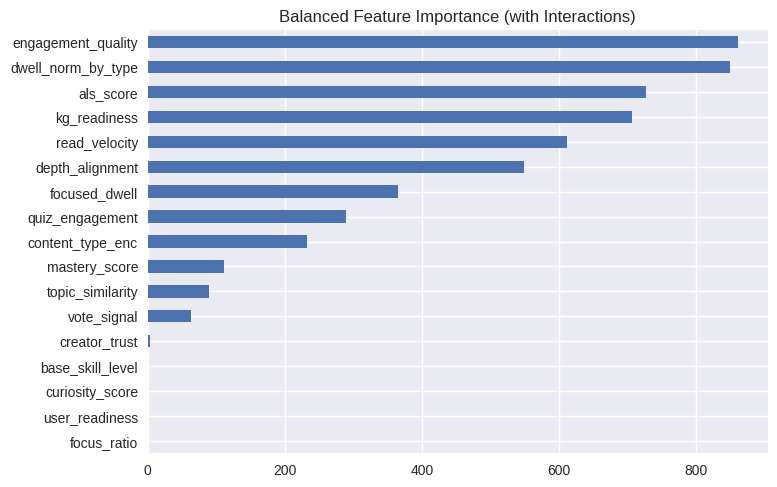

In [28]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import RobustScaler
import joblib, json
import matplotlib.pyplot as plt

print("፦ Step 5: Training Balanced Knova Ranker (Feature Interaction Pass)...")

df = pd.read_csv('knova_features_final.csv')

# --- FIX 1: REFINED RELEVANCE LABEL ---
df['relevance'] = (
    (df['actual_dwell_sec'] >= df['expected_read_time_sec'] * 0.6).astype(int) +
    ((df['upvote'] == 1) |
     ((df['type'] == 'flashcard') & (df['card_flipped'] == 1)) |
     (df['quiz_correct'] == 1)).astype(int) +
    ((df['upvote'] == 1) & ((df['quiz_correct'] == 1) | (df['card_flipped'] == 1))).astype(int)
).clip(0, 3)

# --- NEW: FEATURE INTERACTIONS TO BOOST WEAK SIGNALS ---
df['engagement_quality'] = (df['dwell_norm_by_type'] * 0.6 + df['vote_signal'] * 0.4).clip(-3, 3)
df['user_readiness'] = (df['base_skill_level'] * 0.5 + df['curiosity_score'] * 0.5)
df['focused_dwell'] = (df['dwell_norm_by_type'] * df['focus_ratio']).clip(-3, 3)

# --- FIX 2: FEATURE SCALING ---
scale_features = [
    'mastery_score', 'kg_readiness', 'depth_alignment',
    'topic_similarity', 'als_score', 'curiosity_score', 'base_skill_level',
    'user_readiness' # Scale the new interaction term too
]
scaler = RobustScaler()
df[scale_features] = scaler.fit_transform(df[scale_features])
joblib.dump(scaler, 'knova_feature_scaler.pkl')

FEATURES_ALL = [
    'dwell_norm_by_type', 'read_velocity', 'vote_signal', 'quiz_engagement',
    'focus_ratio', 'mastery_score', 'kg_readiness', 'depth_alignment',
    'base_skill_level', 'curiosity_score', 'topic_similarity', 'als_score',
    'content_type_enc', 'creator_trust', 'engagement_quality', 'user_readiness', 'focused_dwell'
]

# Train/Val Split
df = df.sort_values('user_id').reset_index(drop=True)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, df['relevance'], groups=df['user_id']))

df_tr, df_val = df.iloc[train_idx], df.iloc[val_idx]
group_tr = df_tr.groupby('user_id', sort=False).size().values
group_val = df_val.groupby('user_id', sort=False).size().values

# --- FIX 3: TUNED LIGHTGBM RANKER ---
model_ranker = lgb.LGBMRanker(
    objective='lambdarank', metric='ndcg', ndcg_eval_at=[5, 10, 20],
    label_gain=[0, 1, 3, 7], n_estimators=500, num_leaves=63,
    learning_rate=0.03, feature_fraction=0.7, reg_alpha=0.1, reg_lambda=0.5,
    random_state=42
)

model_ranker.fit(
    df_tr[FEATURES_ALL], df_tr['relevance'], group=group_tr,
    eval_set=[(df_val[FEATURES_ALL], df_val['relevance'])],
    eval_group=[group_val], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

# --- FIX 4: FULL EVALUATION ---
def full_evaluation(model, df_eval, features):
    metrics = {'ndcg_10': [], 'prec_10': [], 'engagement': []}
    for uid, udf in df_eval.groupby('user_id'):
        if len(udf) < 2: continue
        true_rel = udf['relevance'].values
        pred_scores = model.predict(udf[features])
        if len(np.unique(true_rel)) > 1:
            metrics['ndcg_10'].append(ndcg_score([true_rel], [pred_scores], k=10))
        top_10 = np.argsort(pred_scores)[::-1][:10]
        metrics['prec_10'].append((true_rel[top_10] > 0).mean())
        metrics['engagement'].append((true_rel[np.argsort(pred_scores)[::-1][:max(1, int(len(udf)*0.2))]] >= 2).sum() / len(udf))

    print(f"\n። FULL EVALUATION:")
    print(f"   NDCG@10: {np.mean(metrics['ndcg_10']):.4f} | Prec@10: {np.mean(metrics['prec_10']):.4f} | Engagement: {np.mean(metrics['engagement']):.4f}")

full_evaluation(model_ranker, df_val, FEATURES_ALL)

# Feature Importance Plot
importances = model_ranker.feature_importances_
pd.Series(importances, index=FEATURES_ALL).sort_values().plot(kind='barh', title='Balanced Feature Importance (with Interactions)')
plt.show()

joblib.dump(model_ranker, 'knova_content_ranker.pkl')
with open('knova_feature_config.json', 'w') as f:
    json.dump({'FEATURES_ALL': FEATURES_ALL, 'scale_features': scale_features}, f)

In [29]:
# ==============================================================================
# STEP 6: CONSOLIDATED FEED WITH RANDOMIZED THOMPSON POSITIONS
# ==============================================================================
import joblib, json
import pandas as pd
import numpy as np

print("፦ Generating Randomized Production Feed...")

model = joblib.load('knova_content_ranker.pkl')
scaler = joblib.load('knova_feature_scaler.pkl')
ts = joblib.load('knova_thompson_sampler.pkl')
df_features = pd.read_csv('knova_features_final.csv')
df_content = pd.read_csv('knova_content.csv')

with open('knova_feature_config.json') as f: config = json.load(f)
features = config['FEATURES_ALL']
scale_cols = config['scale_features']

def generate_feed(user_id, model, ts_sampler, n_ranked=20, n_exp=5):
    user_pool = df_features[df_features['user_id'] == user_id].copy()
    if len(user_pool) == 0: return None

    # Generate interaction features locally for the user pool
    user_pool['engagement_quality'] = (user_pool['dwell_norm_by_type'] * 0.6 + user_pool['vote_signal'] * 0.4).clip(-3, 3)
    user_pool['user_readiness'] = (user_pool['base_skill_level'] * 0.5 + user_pool['curiosity_score'] * 0.5)
    user_pool['focused_dwell'] = (user_pool['dwell_norm_by_type'] * user_pool['focus_ratio']).clip(-3, 3)

    # Apply Scaling
    user_pool[scale_cols] = scaler.transform(user_pool[scale_cols])

    # Predict & Normalize
    raw_scores = model.predict(user_pool[features].fillna(0))
    s_min, s_max = raw_scores.min(), raw_scores.max()
    user_pool['predicted_score'] = (raw_scores - s_min) / (s_max - s_min) if s_max > s_min else 0.5

    ranked = user_pool.nlargest(n_ranked, 'predicted_score')[['content_id', 'predicted_score']].copy()
    ranked['source'] = 'ranked'
    ranked_list = ranked.to_dict('records')

    # Thompson Exploration (Unseen)
    seen_ids = set(user_pool['content_id'].values)
    unseen_ids = df_content[~df_content['content_id'].isin(seen_ids)]['content_id'].values
    exp_ids = ts_sampler.sample(unseen_ids, n=n_exp)

    # --- RANDOM THOMPSON POSITIONS ---
    total_slots = n_ranked + n_exp
    rng = np.random.default_rng(seed=int(user_id) * 31 + 7)
    available = list(range(2, total_slots)) # Protect top 2
    rng.shuffle(available)

    thompson_positions = set()
    for pos in available:
        if len(thompson_positions) >= n_exp: break
        if not any(abs(pos - p) <= 1 for p in thompson_positions):
            thompson_positions.add(pos)
    thompson_positions = sorted(thompson_positions)

    # Build feed
    combined = []
    r_idx, e_idx = 0, 0
    for slot in range(total_slots):
        if slot in thompson_positions and e_idx < len(exp_ids):
            # Score slightly below surrounding context for UI consistency
            nearby_score = ranked_list[min(r_idx, len(ranked_list)-1)]['predicted_score'] * 0.85
            combined.append({'content_id': exp_ids[e_idx], 'predicted_score': round(nearby_score, 4), 'source': 'thompson'})
            e_idx += 1
        elif r_idx < len(ranked_list):
            combined.append(ranked_list[r_idx])
            r_idx += 1

    return pd.DataFrame(combined).merge(df_content[['content_id', 'topic', 'type', 'difficulty_score']], on='content_id')

# Sample feed for first 3 users to demonstrate random seeding
for i in range(3):
    uid = df_features['user_id'].unique()[i]
    feed = generate_feed(uid, model, ts)
    print(f"\n✅ Feed for User {uid} (Randomized Positions):")
    display(feed[['content_id', 'topic', 'type', 'predicted_score', 'source']].head(10))

፦ Generating Randomized Production Feed...

✅ Feed for User 1 (Randomized Positions):


,content_id,topic,type,predicted_score,source
0,4520,Structural Engineering,text_content,1.000000,ranked
1,5988,Machine Learning,flashcard,0.949238,ranked
2,4978,Agronomy,short_note,0.947402,ranked
3,6232,Cricket Analytics,mcq,0.714100,thompson
4,5070,Macroeconomics,flashcard,0.840120,ranked
5,5766,Machine Learning,mcq,0.617303,ranked
6,3389,Genetics,mcq,0.606382,ranked
7,187,Agronomy,mcq,0.579251,ranked
8,1355,Cell Biology,mcq,0.471100,thompson
9,3040,Linguistics,short_note,0.554225,ranked



✅ Feed for User 2 (Randomized Positions):


,content_id,topic,type,predicted_score,source
0,6801,Human Anatomy,mcq,1.000000,ranked
1,8737,Cricket Analytics,mcq,0.973272,ranked
2,5841,Psychology,flashcard,0.640406,ranked
3,3007,Cell Biology,short_note,0.392619,ranked
4,7146,Climatology,short_note,0.372625,ranked
5,1260,Calculus,text_content,0.364429,ranked
6,2957,Nepalese Arts,flashcard,0.255600,thompson
7,6244,Archeology,mcq,0.300649,ranked
8,5661,Fluid Mechanics,mcq,0.300643,ranked
9,2170,Corporate Finance,flashcard,0.214847,ranked



✅ Feed for User 3 (Randomized Positions):


,content_id,topic,type,predicted_score,source
0,8886,Hydrology,mcq,1.000000,ranked
1,4038,Agronomy,mcq,1.000000,ranked
2,222,DBMS,flashcard,0.687272,ranked
3,9470,Machine Learning,flashcard,0.686030,ranked
4,3261,Cinema Studies,mcq,0.654222,ranked
5,2533,Soil Mechanics,short_note,0.498000,thompson
6,6643,Cinema Studies,flashcard,0.585828,ranked
7,8222,Modern English Fiction,flashcard,0.496200,thompson
8,2073,Cinema Studies,flashcard,0.583752,ranked
9,6438,Classical Mechanics,flashcard,0.510808,ranked


In [30]:
import shutil
import os

# Target directory
target_dir = '/content/sample_data'
os.makedirs(target_dir, exist_ok=True)

# 1. Get all files in the current directory (excluding hidden system files)
all_files = [f for f in os.listdir('.') if os.path.isfile(f) and not f.startswith('.')]

print(f"፦ Copying {len(all_files)} files to {target_dir}...")

for f in all_files:
    try:
        shutil.copy(f, os.path.join(target_dir, f))
    except Exception as e:
        print(f'❌ ERROR copying {f}: {e}')

# 2. Explicitly remove .ipynb_checkpoints if it exists in sample_data
checkpoint_path = os.path.join(target_dir, '.ipynb_checkpoints')
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
    print("✅ Removed .ipynb_checkpoints from packaging directory.")

# 3. Zip the cleaned sample_data folder
shutil.make_archive('knova_full_package', 'zip', target_dir)
print(f'\n✅ knova_full_package.zip is ready to download.')

፦ Copying 22 files to /content/sample_data...
✅ Removed .ipynb_checkpoints from packaging directory.

✅ knova_full_package.zip is ready to download.


In [32]:
from google.colab import files
files.download('knova_full_package.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>